# Análise Exploratória de Dados (EDA) — ESG Scoring
### Projeto ML I — CESAR School

---

## 1. Introdução

### 1.2. Contextualização

**Problema abordado:**  
O problema consiste em prever o nível de desempenho ESG (Environmental, Social e Governance) de empresas com base em suas características setoriais e de mercado. O target é a variável `total_level`, que classifica as empresas como **High** ou **Medium**, representando uma tarefa de **classificação binária**.

**Objetivo da solução:**  
Construir um modelo de machine learning capaz de classificar o nível ESG total de uma empresa a partir de atributos como indústria, bolsa de valores, moeda e subcategorias de notas ESG (ambiental, social e governança).

**Domínio da aplicação:**  
O dataset pertence ao domínio de **finanças sustentáveis e ESG (Environmental, Social, Governance)**. Os dados foram coletados de relatórios de ESG de empresas listadas nas bolsas NYSE e NASDAQ, com avaliação realizada em 2022.

**Importância da EDA para o projeto:**  
A análise exploratória é essencial para entender a estrutura dos dados, identificar redundâncias (como o data leakage potencial entre scores numéricos e grades categóricos), tratar valores ausentes, verificar o balanceamento das classes e selecionar as features mais informativas antes do treinamento do modelo. Sem uma EDA criteriosa, corre-se o risco de construir modelos com desempenho artificialmente inflado ou enviesado.

---
## Dicionário de Dados — Base Bronze

| Coluna | Descrição | Tipo | Valores possíveis / Exemplo |
|--------|-----------|------|-----------------------------|
| ticker | Código de negociação da empresa na bolsa | String | dis, gm, gww |
| name | Nome da empresa | String | Walt Disney Co |
| currency | Moeda de negociação | String | USD, CNY, EUR, CHF, BRL |
| exchange | Bolsa de valores onde a empresa está listada | String | NEW YORK STOCK EXCHANGE, INC. / NASDAQ NMS - GLOBAL MARKET |
| industry | Setor de atuação da empresa | String (48 categorias) | Technology, Biotechnology, Health Care |
| logo | URL do logotipo da empresa | String | https://static.finnhub.io/... |
| weburl | URL do site oficial da empresa | String | https://thewaltdisneycompany.com/ |
| environment_grade | Nota de desempenho ambiental (escala bond-rating) | Categórico (ordinal) | C, B, BB, BBB, A, AA → Ex: A |
| environment_level | Nível de desempenho ambiental | Categórico (ordinal) | Low, Medium, High, Excellent → Ex: High |
| social_grade | Nota de desempenho social (escala bond-rating) | Categórico (ordinal) | C, B, BB, BBB, A, AA → Ex: BB |
| social_level | Nível de desempenho social | Categórico (ordinal) | Low, Medium, High, Excellent → Ex: Medium |
| governance_grade | Nota de governança corporativa (escala bond-rating) | Categórico (ordinal) | C, B, BB, BBB, A, AA → Ex: BB |
| governance_level | Nível de governança corporativa | Categórico (ordinal) | Low, Medium, High, Excellent → Ex: Medium |
| environment_score | Score numérico do pilar ambiental | Inteiro | 200 a 719 → Ex: 510 |
| social_score | Score numérico do pilar social | Inteiro | 160 a 667 → Ex: 316 |
| governance_score | Score numérico do pilar de governança | Inteiro | 75 a 475 → Ex: 321 |
| total_score | Soma dos três sub-scores (E + S + G) | Inteiro | 600 a 1536 → Ex: 1147 |
| last_processing_date | Data de processamento dos dados | String | 19-04-2022 |
| total_grade | Nota ESG geral da empresa (escala bond-rating) | Categórico (ordinal) | B, BB, BBB, A → Ex: BBB |
| total_level | **TARGET** — Nível ESG geral da empresa | Categórico (ordinal) | Medium, High → Ex: High |
| cik | Código identificador da empresa na SEC (regulador americano) | Inteiro | 1744489 |

---
## 2. Inspeção dos Dados

### 2.1 Importação das bibliotecas

Bibliotecas utilizadas no projeto e suas respectivas finalidades:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas importadas com sucesso!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

Bibliotecas importadas com sucesso!
Pandas: 2.3.3 | NumPy: 2.2.6


### 2.2 Carregamento dos dados

Dataset está no formato parquet e para engine utilizaremos pyarrow, pois é mais rápido e amplamente suportado.

In [5]:
DATA_PATH = '../data/bronze/esg_reporting_bronze.parquet'
df = pd.read_parquet(DATA_PATH, engine='pyarrow')

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')

Dataset carregado: 722 linhas x 21 colunas


### 2.3 Primeiras linhas e estrutura

In [6]:
df.head()

,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,...,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,...,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,...,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,...,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,...,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,...,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258


### 2.4 Tipos das variáveis

In [7]:
print(df.dtypes)
print(f'\nVariáveis numéricas : {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Variáveis categóricas: {df.select_dtypes(exclude=np.number).columns.tolist()}')

ticker                  object
name                    object
currency                object
exchange                object
industry                object
logo                    object
weburl                  object
environment_grade       object
environment_level       object
social_grade            object
social_level            object
governance_grade        object
governance_level        object
environment_score        int64
social_score             int64
governance_score         int64
total_score              int64
last_processing_date    object
total_grade             object
total_level             object
cik                      int64
dtype: object

Variáveis numéricas : ['environment_score', 'social_score', 'governance_score', 'total_score', 'cik']
Variáveis categóricas: ['ticker', 'name', 'currency', 'exchange', 'industry', 'logo', 'weburl', 'environment_grade', 'environment_level', 'social_grade', 'social_level', 'governance_grade', 'governance_level', 'last_processing_date'

### 2.5 Dimensão da base

In [8]:
print(f'Dimensão: {df.shape[0]} registros | {df.shape[1]} colunas')

Dimensão: 722 registros | 21 colunas


### 2.6 Valores ausentes

In [9]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, '% do Total': null_pct})
null_df = null_df[null_df['Nulos'] > 0].sort_values('% do Total', ascending=False)

print('=== Colunas com valores ausentes ===')
print(null_df)
print(f'\nTotal de colunas sem nulos: {(nulls == 0).sum()} de {df.shape[1]}')

=== Colunas com valores ausentes ===
          Nulos  % do Total
logo         20        2.77
weburl       16        2.22
industry     13        1.80

Total de colunas sem nulos: 18 de 21


### 2.7 Registros duplicados

In [10]:
n_dup = df.duplicated().sum()
n_dup_ticker = df.duplicated(subset='ticker').sum()
print(f'Linhas duplicadas  : {n_dup}')
print(f'Tickers duplicados : {n_dup_ticker}')
print('Conclusão: Dataset sem duplicatas — cada linha representa uma empresa única.')

Linhas duplicadas  : 0
Tickers duplicados : 0
Conclusão: Dataset sem duplicatas — cada linha representa uma empresa única.


### 2.8 Cardinalidade das variáveis categóricas

In [11]:
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    print(f'{col:25s}: {df[col].nunique():4d} únicos')

ticker                   :  722 únicos
name                     :  722 únicos
currency                 :    5 únicos
exchange                 :    2 únicos
industry                 :   47 únicos
logo                     :  702 únicos
weburl                   :  706 únicos
environment_grade        :    5 únicos
environment_level        :    3 únicos
social_grade             :    6 únicos
social_level             :    4 únicos
governance_grade         :    4 únicos
governance_level         :    3 únicos
last_processing_date     :   30 únicos
total_grade              :    4 únicos
total_level              :    2 únicos


---
## 3. Estatísticas Descritivas

### 3.1 Estatísticas dos scores numéricos

In [12]:
score_cols = ['environment_score', 'social_score', 'governance_score', 'total_score']
desc = df[score_cols].describe().T
desc['cv_%']     = (desc['std'] / desc['mean'] * 100).round(2)
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,cv_%
environment_score,722.0,404.81,145.10,200.0,240.0,483.0,518.75,719.0,35.85
social_score,722.0,292.18,57.02,160.0,243.0,302.0,322.75,667.0,19.51
governance_score,722.0,278.76,47.03,75.0,235.0,300.0,310.00,475.0,16.87
total_score,722.0,975.75,218.75,600.0,763.0,1046.0,1144.00,1536.0,22.42


### 3.2 Interpretação das estatísticas descritivas

INTERPRETAÇÃO:
_________________________________________________________________________________
• environment_score: média=405, mediana=483. Média < mediana indica assimetria negativa — grupo expressivo de scores altos + cauda inferior.  
  CV=35.8%: alta dispersão relativa entre as empresas.

• social_score: média=292, mediana=302. Distribuição quase simétrica.  
  CV=19.5%: dispersão moderada — empresas mais homogêneas no pilar Social.

• governance_score: média=279, mediana=300. CV=16.9% — o pilar mais homogêneo.  
  Menor variação entre setores e empresas.

• total_score: média=976, mediana=1046. Intervalo [600, 1536].  
  É a soma exata dos 3 sub-scores — não usar como feature (leakage direto).

### 3.3 Frequência das variáveis categóricas relevantes

Colunas de interesse: `total_level`, `total_grade`, `environment_grade`, `social_grade`, `governance_grade` e `exchange`.

Essas variáveis foram selecionadas por terem relevância direta para o problema ESG: `total_level` é o target, `total_grade` é sua versão mais granular, as três grades (E, S, G) são as principais features candidatas para o Cenário B, e `exchange` apresenta diferença de desempenho ESG entre NYSE e NASDAQ. As demais categóricas (ticker, name, logo, weburl, currency) foram descartadas por serem identificadores ou metadados sem valor preditivo.

In [13]:
cat_interest = ['total_level', 'total_grade', 'environment_grade',
                'social_grade', 'governance_grade', 'exchange']

for col in cat_interest:
    freq = df[col].value_counts()
    pct  = (freq / len(df) * 100).round(1)
    print(f'\n{col.upper()}')
    print(pd.concat([freq, pct], axis=1, keys=['qtd', '%']).to_string())


TOTAL_LEVEL
             qtd     %
total_level           
High         451  62.5
Medium       271  37.5

TOTAL_GRADE
             qtd     %
total_grade           
BBB          368  51.0
B            167  23.1
BB           104  14.4
A             83  11.5

ENVIRONMENT_GRADE
                   qtd     %
environment_grade           
A                  321  44.5
B                  255  35.3
BB                  69   9.6
BBB                 45   6.2
AA                  32   4.4

SOCIAL_GRADE
              qtd     %
social_grade           
BB            441  61.1
B             262  36.3
BBB            13   1.8
A               4   0.6
CCC             1   0.1
AA              1   0.1

GOVERNANCE_GRADE
                  qtd     %
governance_grade           
BB                434  60.1
B                 282  39.1
BBB                 5   0.7
C                   1   0.1

EXCHANGE
                               qtd     %
exchange                                
NEW YORK STOCK EXCHANGE, INC.  377  52

---
## 4. Tratamento dos Dados

### 4.1 Remoção de colunas irrelevantes para modelagem

Colunas a serem removidas e as devidas justificativas:
* **ticker, name** — identificadores únicos, sem poder preditivo
* **logo, weburl** — metadados visuais/web, irrelevantes para ESG
* **cik** — código regulatório SEC, apenas identificador
* **last_processing_date** — data de processamento, não atributo da empresa
* **total_score** — variável derivada diretamente dos sub-scores ESG, introduzindo leakage e redundância informacional, já que o target é construído a partir dessa mesma composição.
* **total_grade** — variável derivada diretamente de total_score, causando vazamento de informação e possível inflação artificial das métricas de desempenho.

In [14]:
cols_to_drop = ['ticker', 'name', 'logo', 'weburl', 'cik',
                'last_processing_date', 'total_score', 'total_grade']

df_clean = df.drop(columns=cols_to_drop).copy()
print(f'Shape após remoção: {df_clean.shape}')

Shape após remoção: (722, 13)


### 4.2 Tratamento de valores ausentes

A única feature que possui nulos é a `industry`, como há 47 categorias e poucos nulos (13 registros = 1.8%), preenchemos com `'Unknown'` para não perder registros válidos.

In [15]:
print(f'Nulos em industry ANTES: {df_clean["industry"].isnull().sum()}')
df_clean['industry'] = df_clean['industry'].fillna('Unknown')
print(f'Nulos em industry DEPOIS: {df_clean["industry"].isnull().sum()}')
print(f'Total de nulos no dataset limpo: {df_clean.isnull().sum().sum()}')

Nulos em industry ANTES: 13
Nulos em industry DEPOIS: 0
Total de nulos no dataset limpo: 0


### 4.3 Encoding ordinal das grades ESG

As grades possuem escala ordinal então podemos utilizar o OrdinalEncoder para preservar a hierarquia: **C < CCC < B < BB < BBB < A < AA**.

In [16]:
GRADE_ORDER = ['C', 'CCC', 'B', 'BB', 'BBB', 'A', 'AA']
grade_cols  = ['environment_grade', 'social_grade', 'governance_grade']

oe = OrdinalEncoder(
    categories=[GRADE_ORDER] * 3,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df_clean[grade_cols] = oe.fit_transform(df_clean[grade_cols])

print('Mapeamento ordinal (bond-rating scale):')
for i, g in enumerate(GRADE_ORDER):
    print(f'  {g:4s} → {i}')

df_clean['target'] = (df_clean['total_level'] == 'High').astype(int)
print(f'\nTarget: High=1 ({(df_clean["target"]==1).sum()}) | Medium=0 ({(df_clean["target"]==0).sum()})')

Mapeamento ordinal (bond-rating scale):
  C    → 0
  CCC  → 1
  B    → 2
  BB   → 3
  BBB  → 4
  A    → 5
  AA   → 6

Target: High=1 (451) | Medium=0 (271)


### 4.4 Encoding das demais variáveis

`exchange` e `currency` utilizaremos LabelEncoder, pois possuem baixa cardinalidade (2 e 5 valores). Para industry utilizamos Frequency Encoding na EDA. Na etapa de modelagem, a variável poderá ser substituída por Target Encoding com validação cruzada, devido à sua alta cardinalidade, evitando aumento excessivo de dimensionalidade e sparsidade nos dados. Para os levels utilizamos OrdinalEncoder preservando a ordem Low < Medium < High < Excellent.

In [17]:
le = LabelEncoder()
df_clean['exchange_enc'] = le.fit_transform(df_clean['exchange'])
df_clean['currency_enc'] = le.fit_transform(df_clean['currency'])

industry_freq = df_clean['industry'].value_counts().to_dict()
df_clean['industry_freq'] = df_clean['industry'].map(industry_freq)

LEVEL_ORDER = ['Low', 'Medium', 'High', 'Excellent']
level_cols  = ['environment_level', 'social_level', 'governance_level']
oe_level = OrdinalEncoder(
    categories=[LEVEL_ORDER] * 3,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df_clean[level_cols] = oe_level.fit_transform(df_clean[level_cols])

print('Encodings aplicados:')
print('  exchange → exchange_enc  (LabelEncoder, 2 categorias)')
print('  currency → currency_enc  (LabelEncoder, 5 categorias)')
print('  industry → industry_freq (Frequency Encoding, 48 categorias)')
print('  *_level  → ordinal enc.  (Low=0, Medium=1, High=2, Excellent=3)')
print(f'\nShape final: {df_clean.shape}')

Encodings aplicados:
  exchange → exchange_enc  (LabelEncoder, 2 categorias)
  currency → currency_enc  (LabelEncoder, 5 categorias)
  industry → industry_freq (Frequency Encoding, 48 categorias)
  *_level  → ordinal enc.  (Low=0, Medium=1, High=2, Excellent=3)

Shape final: (722, 17)


### 4.5 Definição dos dois cenários para análise de leakage

* **Cenário A** (ocorre leakage): Com sub-scores numéricos — os sub-scores possuem relação direta com a construção do target, introduzindo vazamento de informação e potencial inflação artificial da performance do modelo.
* **Cenário B** (modelo real): Sem sub-scores — apenas grades, levels e contexto da empresa. O modelo aprende padrões genuínos.

In [18]:
FEATURES_A = [
    'environment_score', 'social_score', 'governance_score',
    'environment_grade', 'social_grade', 'governance_grade',
    'environment_level', 'social_level', 'governance_level',
    'exchange_enc', 'currency_enc', 'industry_freq'
]

FEATURES_B = [
    'environment_grade', 'social_grade', 'governance_grade',
    'exchange_enc', 'currency_enc', 'industry_freq'
]

TARGET = 'target'
X_A = df_clean[FEATURES_A]
X_B = df_clean[FEATURES_B]
y   = df_clean[TARGET]

print(f'Cenário A: {len(FEATURES_A)} features (com sub-scores)')
print(f'Cenário B: {len(FEATURES_B)} features (sem sub-scores)')
print(f'Distribuição do target: {y.value_counts().to_dict()}')

Cenário A: 12 features (com sub-scores)
Cenário B: 6 features (sem sub-scores)
Distribuição do target: {1: 451, 0: 271}


---
## 5. Análise Exploratória e Visualizações

### VIZ 1 — Distribuição das classes (target)

FileNotFoundError: [Errno 2] No such file or directory: 'figures/viz1_distribuicao_classes.png'

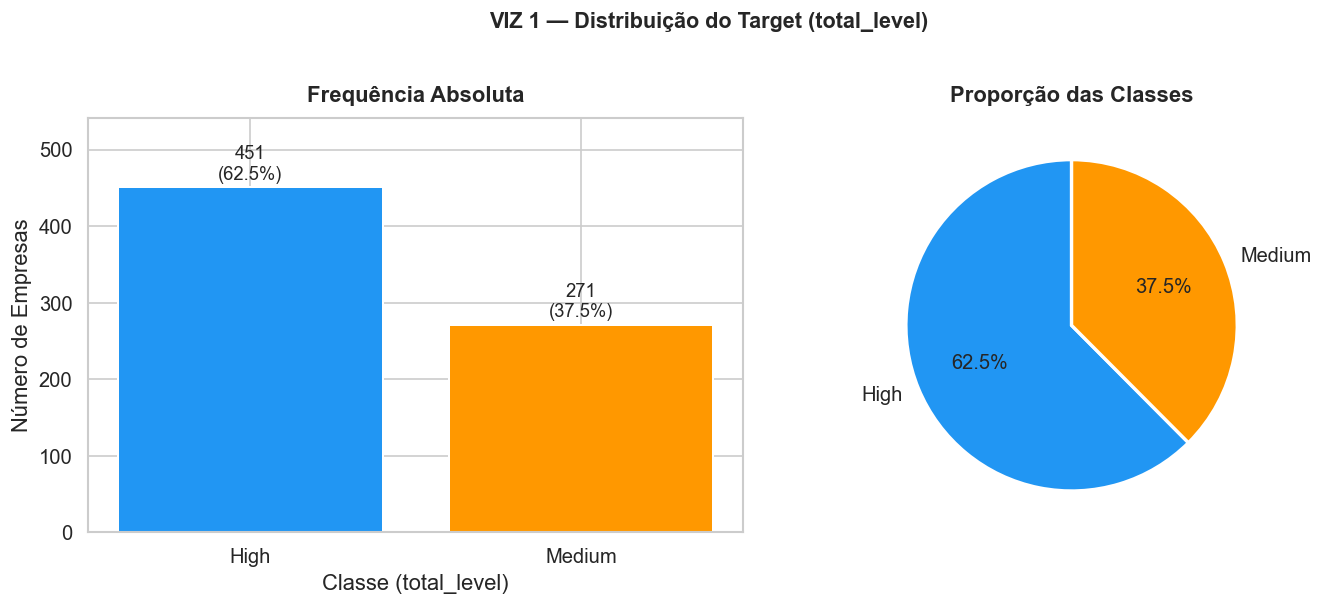

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['total_level'].value_counts()
colors = ['#2196F3', '#FF9800']

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Frequência Absoluta', fontweight='bold', pad=10)
axes[0].set_ylabel('Número de Empresas')
axes[0].set_xlabel('Classe (total_level)')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_ylim(0, max(counts.values) * 1.2)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontweight='bold', pad=10)

plt.suptitle('VIZ 1 — Distribuição do Target (total_level)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/viz1_distribuicao_classes.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Verificar se há desbalanceamento de classes que exija tratamento.  
INTERPRETAÇÃO: 451 empresas High (62.5%) vs 271 Medium (37.5%).  
É possível identificar que na base só existe duas classes registradas: Medium e High. Ou seja, não há nenhuma empresa com maturidade ESG Low ou Excelent. Isso pode ser um problema para previsões futuras, já que a ausência total das classes Low e Excellent impede que o modelo aprenda padrões associados a esses níveis de maturidade ESG.   
Nota-se um desbalanceamento moderado (~1.7:1), o que exige duas medidas complementares já que High é aproximadamente 1.7 vezes maior que a de empresas Medium.

Apesar de não ser um desbalanceamento crítico, ele ainda pode influenciar o treinamento do modelo, fazendo com que a classe majoritária tenha maior peso nas previsões.

Por esse motivo, é válido utilizar `class_weight="balanced"` durante a modelagem, permitindo que o algoritmo atribua maior importância à classe minoritária (Medium) durante o processo de aprendizado.

Além disso, a métrica mais adequada para avaliação é o F1-macro, pois a acurácia simples poderia ser enganosa. Um modelo que sempre previsse a classe High já alcançaria cerca de 62.5% de acerto sem necessariamente aprender padrões relevantes dos dados.

O F1-macro penaliza erros em ambas as classes de forma mais equilibrada, tornando a avaliação mais confiável em cenários com desbalanceamento.

### VIZ 2 — Distribuição dos sub-scores por classe

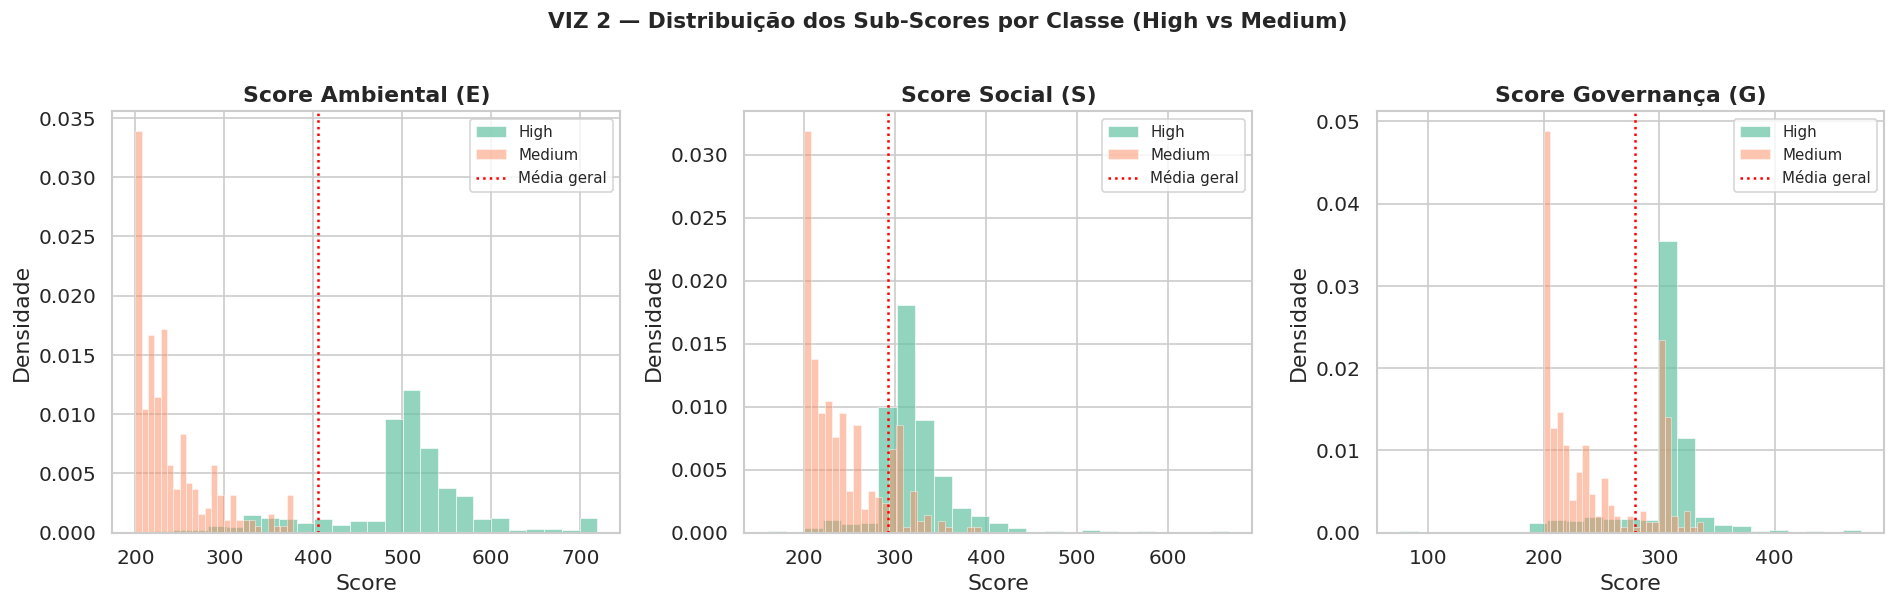

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

score_info = [
    ('environment_score', 'Score Ambiental (E)', '#4CAF50'),
    ('social_score',      'Score Social (S)',     '#2196F3'),
    ('governance_score',  'Score Governança (G)', '#9C27B0'),
]

for ax, (col, title, color) in zip(axes, score_info):
    for level, alpha in [('High', 0.7), ('Medium', 0.5)]:
        subset = df[df['total_level'] == level][col]
        ax.hist(subset, bins=25, alpha=alpha, label=level,
                edgecolor='white', linewidth=0.5, density=True)
    ax.axvline(df[col].mean(), color='red', linestyle=':', linewidth=1.5, label='Média geral')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize=9)

plt.suptitle('VIZ 2 — Distribuição dos Sub-Scores por Classe (High vs Medium)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/viz2_distribuicao_scores.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Identificar qual dos pilares ESG possui maior capacidade de diferenciar empresas Medium e High.

INTERPRETAÇÃO:

- Score Ambiental (E): High = 504 vs Medium = 239 → Delta = 265
- Score Social (S): High = 322 vs Medium = 243 → Delta = 78
- Score Governança (G): High = 300 vs Medium = 243 → Delta = 57

O pilar ambiental apresenta a maior diferença entre as classes, indicando que empresas classificadas como High tendem a possuir desempenho ambiental significativamente superior às empresas Medium.

Já os pilares Social e Governança apresentam diferenças bem menores, sugerindo menor capacidade de separação entre as classes.

Isso indica que o componente ambiental é o principal fator responsável pela distinção entre níveis de maturidade ESG nesta base.

IMPACTO NA MODELAGEM:

A variável `environment_score` provavelmente terá maior importância preditiva durante o treinamento dos modelos, podendo exercer forte influência nas decisões de classificação.

### VIZ 3 — Matriz de Correlação

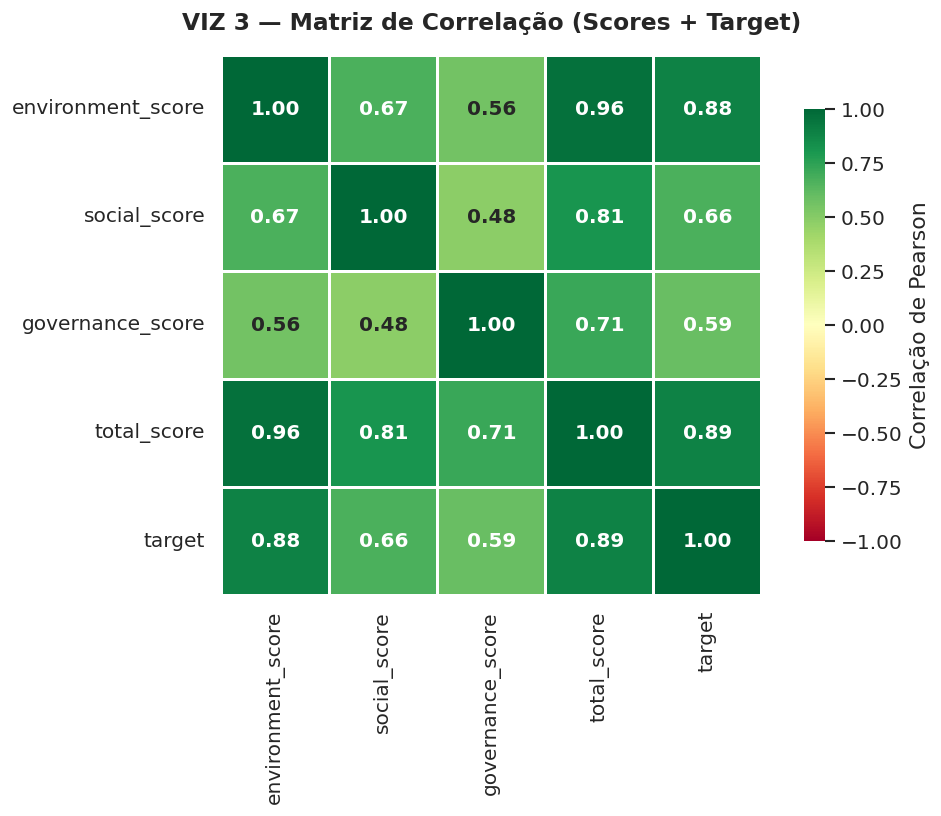

In [ ]:
num_cols_corr = ['environment_score', 'social_score', 'governance_score', 'total_score']
corr_df = df[num_cols_corr].copy()
corr_df['target'] = y.values
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.8,
    cbar_kws={'shrink': 0.8, 'label': 'Correlação de Pearson'},
    ax=ax, annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_title('VIZ 3 — Matriz de Correlação (Scores + Target)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('figures/viz3_correlacao.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Detectar multicolinearidade e possíveis casos de data leakage entre as variáveis e o target.

INTERPRETAÇÃO:

A variável `total_score` apresenta correlação extremamente alta com o target, confirmando a existência de data leakage, já que o score ESG é construído diretamente a partir dos sub-scores.

Além disso, `environment_score` possui a maior correlação com o target, indicando ser o principal fator discriminativo entre as classes.

Também existe multicolinearidade entre os sub-scores ESG, algo esperado, pois todos contribuem para o cálculo do score final.

IMPACTO NA MODELAGEM:

No Cenário B, a remoção dos sub-scores e variáveis derivadas elimina o leakage e reduz os efeitos da multicolinearidade, permitindo uma avaliação mais realista do modelo.

### VIZ 4 — Pairplot dos scores numéricos

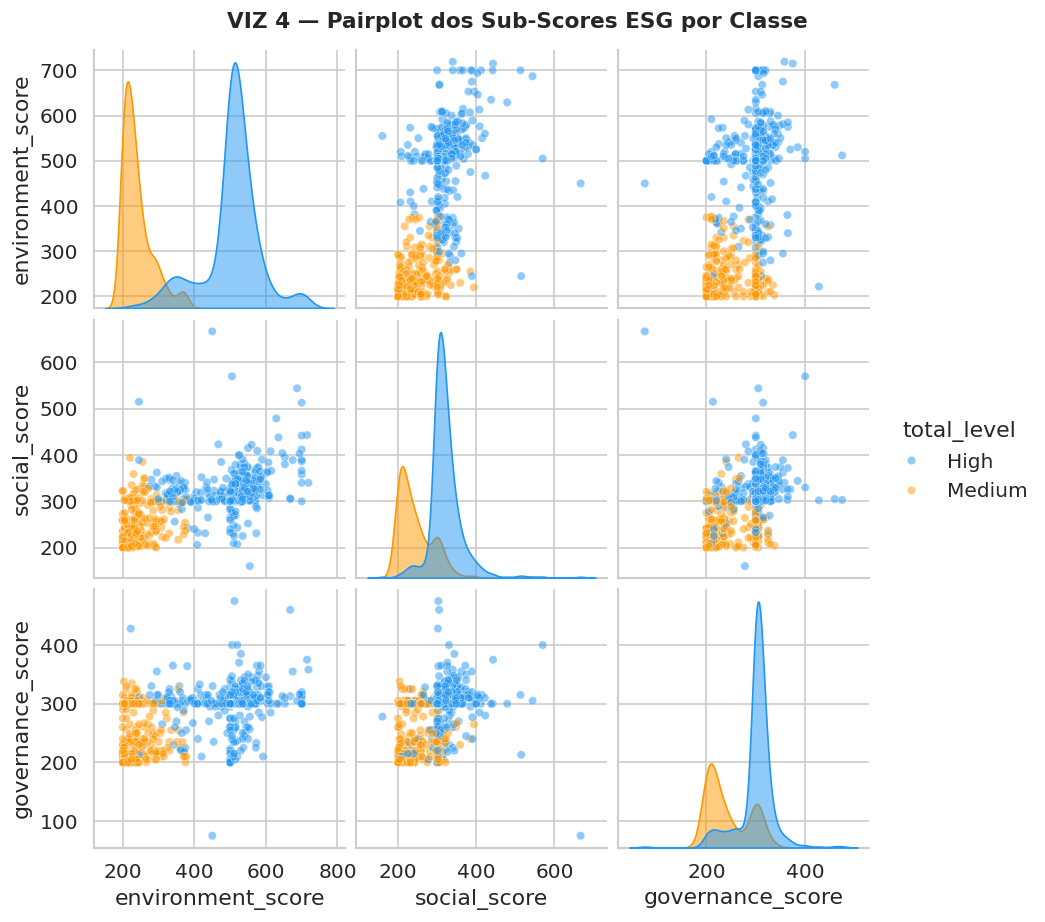

In [ ]:
pair_df = df[['environment_score', 'social_score',
               'governance_score', 'total_level']].copy()

g = sns.pairplot(
    pair_df, hue='total_level',
    palette={'High': '#2196F3', 'Medium': '#FF9800'},
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 25},
    diag_kws={'fill': True, 'alpha': 0.5}
)
g.figure.suptitle('VIZ 4 — Pairplot dos Sub-Scores ESG por Classe', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('figures/viz4_pairplot.png', bbox_inches='tight', dpi=120)
plt.show()

OBJETIVO: Analisar relações bivariadas e a separabilidade visual entre as classes ESG.

INTERPRETAÇÃO:

O `environment_score` apresenta a melhor separação visual entre as classes, com pouca sobreposição nas distribuições, indicando alto poder discriminativo.

Na relação entre `environment_score` e `social_score`, observa-se uma tendência positiva, com empresas High concentradas em regiões de valores mais elevados.

Já a combinação entre `social_score` e `governance_score` apresenta maior sobreposição entre as classes, sugerindo menor capacidade de diferenciação.

IMPACTO NA MODELAGEM:

A separabilidade visual observada indica que os dados possuem sinal preditivo relevante, favorecendo o desempenho de modelos lineares e algoritmos como SVM.

### VIZ 5 — Análise de Outliers — Boxplots

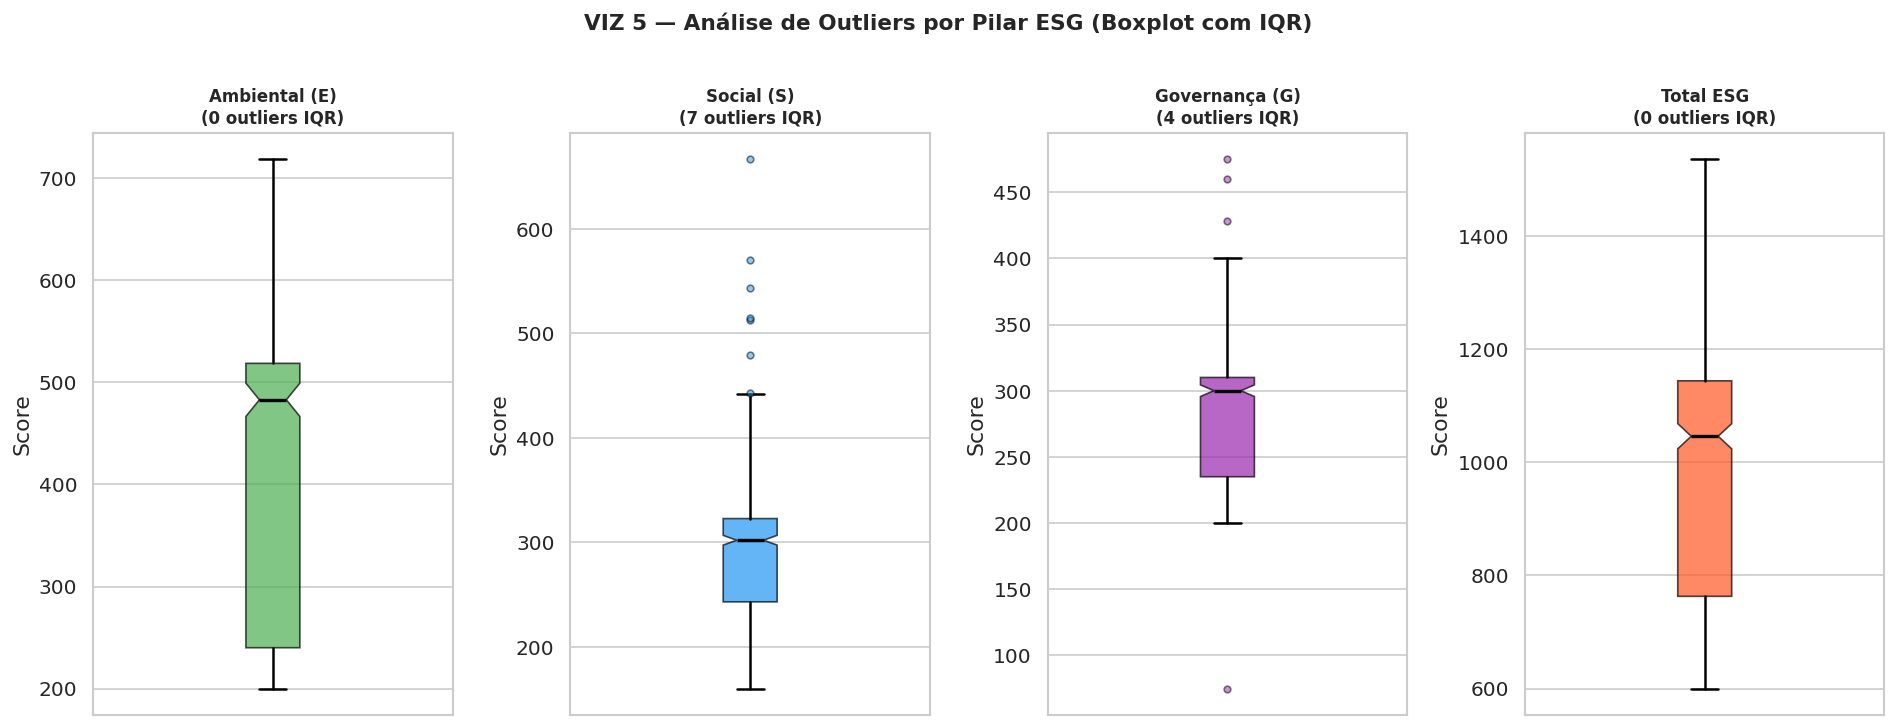

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))
score_cols_all = ['environment_score', 'social_score', 'governance_score', 'total_score']
labels_sc = ['Ambiental (E)', 'Social (S)', 'Governança (G)', 'Total ESG']
colors_sc = ['#4CAF50', '#2196F3', '#9C27B0', '#FF5722']

for ax, col, label, color in zip(axes, score_cols_all, labels_sc, colors_sc):
    bp = ax.boxplot(df[col], patch_artist=True, notch=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor=color, markersize=4, alpha=0.5))
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{label}\n({n_out} outliers IQR)', fontweight='bold', fontsize=10)
    ax.set_ylabel('Score')
    ax.set_xticks([])

plt.suptitle('VIZ 5 — Análise de Outliers por Pilar ESG (Boxplot com IQR)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/viz5_outliers.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Detectar outliers utilizando a regra do IQR (1.5x) e avaliar possíveis assimetrias nas distribuições.

INTERPRETAÇÃO:

- Ambiental (E): IQR = 279 | nenhum outlier relevante identificado
- Social (S): IQR = 80 | presença de outliers
- Governança (G): IQR = 75 | presença de outliers

Os pilares Social e Governança apresentam valores extremos mais frequentes, indicando empresas com desempenho muito acima ou abaixo da média nesses indicadores.

Esses outliers não aparentam ser erros de coleta, mas sim observações reais de empresas com comportamentos ESG mais extremos.

IMPACTO NA MODELAGEM:

Os outliers serão mantidos, pois podem carregar informação preditiva relevante e ajudar o modelo a identificar padrões associados a empresas com perfis ESG muito distintos.

### VIZ 6 — Top 15 indústrias por Score ESG médio

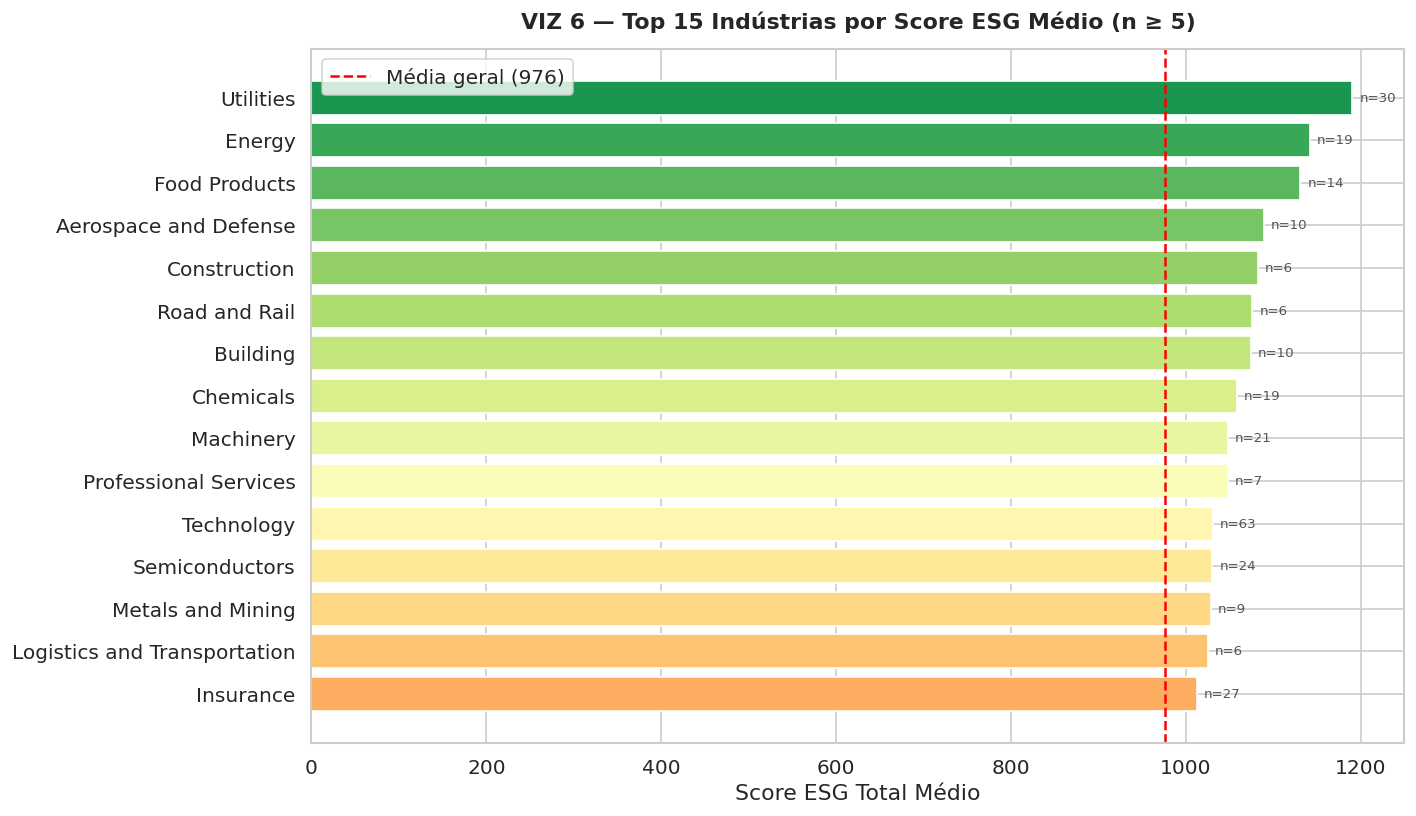

In [ ]:
industry_stats = df.groupby('industry')['total_score'].agg(['mean', 'count'])
industry_stats = industry_stats[industry_stats['count'] >= 5].sort_values('mean', ascending=False)
top15 = industry_stats.head(15)
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top15)))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index, top15['mean'], color=colors_grad[::-1], edgecolor='white')
ax.axvline(df['total_score'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Média geral ({df["total_score"].mean():.0f})')
for bar, (idx, row) in zip(bars, top15.iterrows()):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=8, color='#555')
ax.set_xlabel('Score ESG Total Médio')
ax.set_title('VIZ 6 — Top 15 Indústrias por Score ESG Médio (n ≥ 5)', fontweight='bold', pad=12)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/viz6_industrias.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Avaliar o poder preditivo da variável Industry e identificar padrões setoriais relacionados ao desempenho ESG.

INTERPRETAÇÃO:

Setores mais expostos à regulação ambiental, como Utilities, Chemicals e Materials, tendem a apresentar scores ESG mais elevados, possivelmente devido à maior pressão regulatória e necessidade de transparência.

Isso indica que o setor econômico influencia o comportamento ESG das empresas e pode contribuir para a diferenciação entre as classes.

IMPACTO NA MODELAGEM:

A variável `Industry` possui potencial preditivo relevante, mas devido à sua alta cardinalidade, será mais adequado utilizar Target Encoding durante a modelagem.

### VIZ 7 — Distribuição das grades por pilar

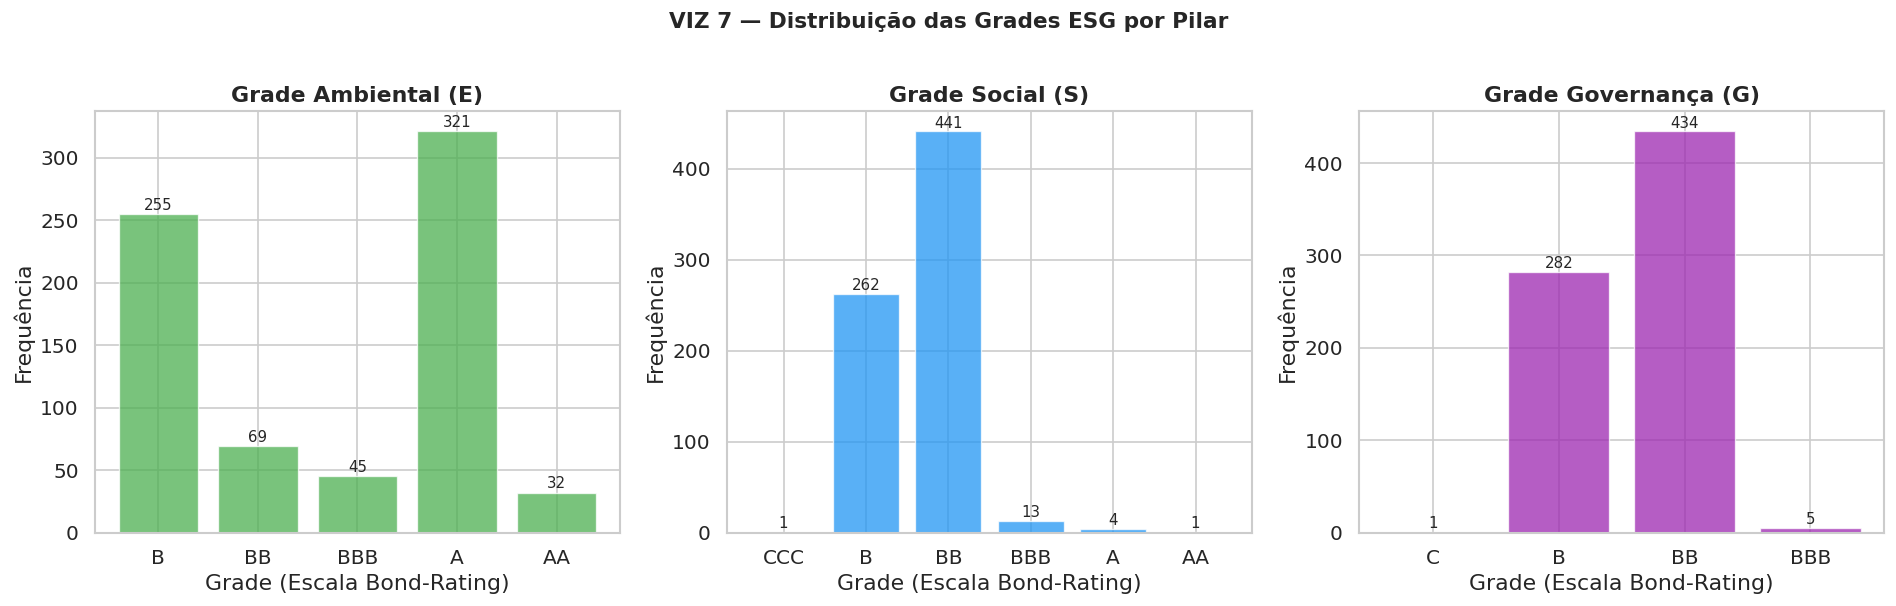

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
grade_order_display = ['C', 'CCC', 'B', 'BB', 'BBB', 'A', 'AA']
grade_raw_cols = ['environment_grade', 'social_grade', 'governance_grade']
titles_g = ['Grade Ambiental (E)', 'Grade Social (S)', 'Grade Governança (G)']
colors_g = ['#4CAF50', '#2196F3', '#9C27B0']

for ax, col, title, color in zip(axes, grade_raw_cols, titles_g, colors_g):
    counts_g = df[col].value_counts()
    order  = [g for g in grade_order_display if g in counts_g.index]
    values = [counts_g.get(g, 0) for g in order]
    bars = ax.bar(order, values, color=color, alpha=0.75, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Grade (Escala Bond-Rating)')
    ax.set_ylabel('Frequência')

plt.suptitle('VIZ 7 — Distribuição das Grades ESG por Pilar', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/viz7_grades.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Verificar concentração e variabilidade das grades em cada pilar ESG.

INTERPRETAÇÃO:

O pilar Ambiental apresenta maior variabilidade entre as empresas, com forte concentração nas grades A (321) e B (255), indicando uma distribuição mais polarizada entre desempenhos altos e intermediários.

Já o pilar Social é amplamente dominado pela grade BB (441), demonstrando baixa dispersão e comportamento mais homogêneo entre as empresas.

No pilar de Governança, as grades BB (434) e B (282) concentram a maior parte das observações, e nenhuma empresa atingiu a classificação AA.

Essa concentração excessiva nas grades BB e B reduz o poder discriminativo dos pilares Social e Governança, dificultando a separação entre as classes ESG.

### VIZ 8 — Score ESG por Bolsa de Valores

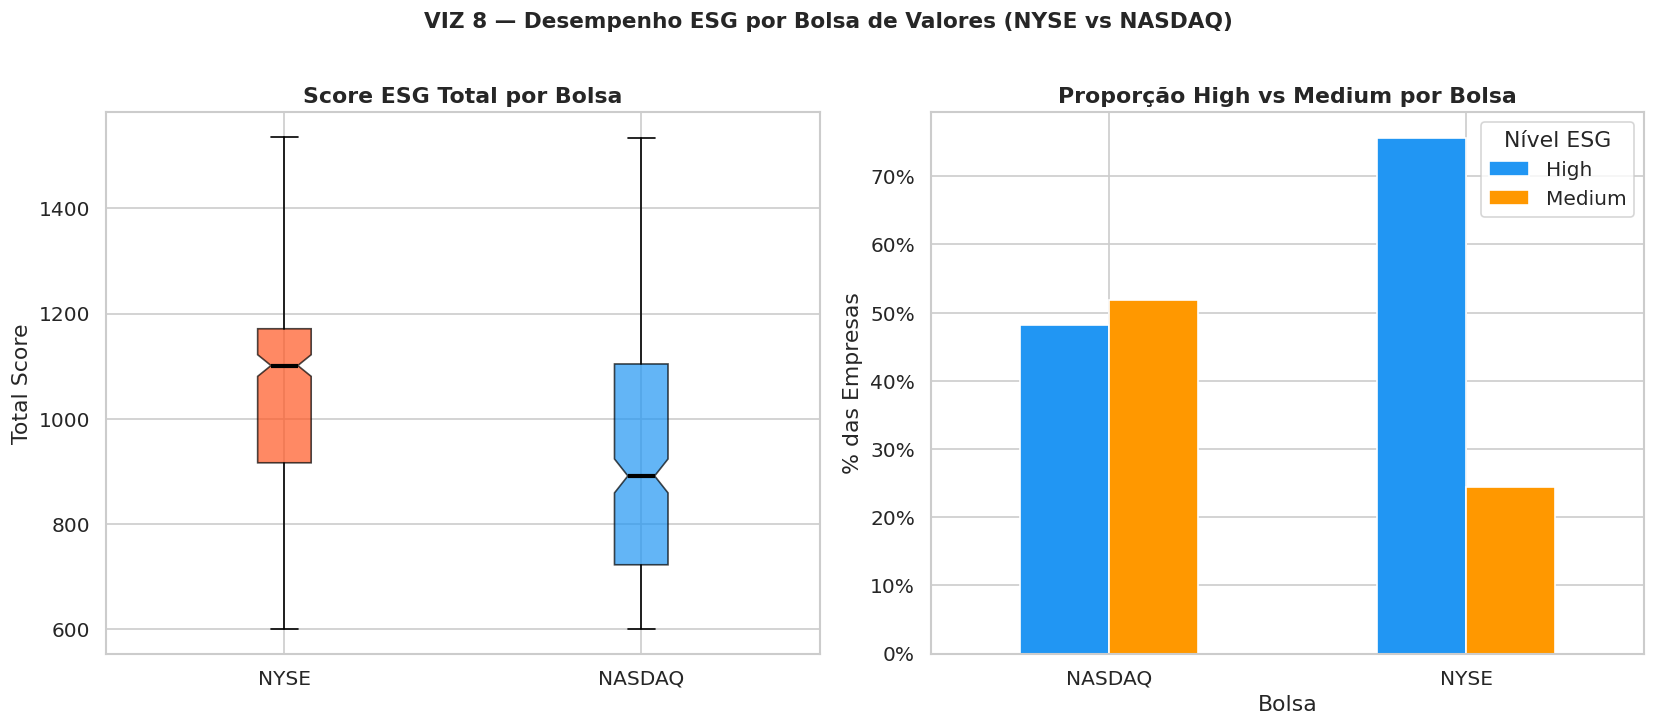

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_exc = df.copy()
df_exc['exchange_short'] = df_exc['exchange'].apply(
    lambda x: 'NYSE' if 'NEW YORK' in x else 'NASDAQ')

data_by_exc = [df_exc[df_exc['exchange_short']=='NYSE']['total_score'],
               df_exc[df_exc['exchange_short']=='NASDAQ']['total_score']]

bp = axes[0].boxplot(data_by_exc, patch_artist=True, notch=True,
                      labels=['NYSE', 'NASDAQ'],
                      boxprops=dict(alpha=0.7),
                      medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], ['#FF5722', '#2196F3']):
    patch.set_facecolor(color)
axes[0].set_title('Score ESG Total por Bolsa', fontweight='bold')
axes[0].set_ylabel('Total Score')

prop = df_exc.groupby(['exchange_short', 'total_level']).size().unstack(fill_value=0)
prop_pct = prop.div(prop.sum(axis=1), axis=0) * 100
prop_pct.plot(kind='bar', ax=axes[1], color=['#2196F3', '#FF9800'], edgecolor='white', rot=0)
axes[1].set_title('Proporção High vs Medium por Bolsa', fontweight='bold')
axes[1].set_ylabel('% das Empresas')
axes[1].set_xlabel('Bolsa')
axes[1].legend(title='Nível ESG')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('VIZ 8 — Desempenho ESG por Bolsa de Valores (NYSE vs NASDAQ)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/viz8_exchange.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Verificar se a bolsa de listagem influencia o nível de maturidade ESG das empresas.

INTERPRETAÇÃO:

Empresas listadas na NYSE apresentam scores ESG ligeiramente superiores às listadas na NASDAQ.

Essa diferença pode estar relacionada ao perfil das empresas de cada bolsa. A NASDAQ concentra mais companhias de tecnologia, setor que tende a apresentar menor pontuação no pilar ambiental quando comparado a segmentos industriais mais regulados.

Apesar disso, a diferença observada é relativamente pequena, indicando que a variável `exchange` possui baixo poder discriminativo quando analisada isoladamente.

IMPACTO NA MODELAGEM:

Mesmo com impacto limitado, a variável pode contribuir como feature contextual de baixo custo, adicionando informação complementar ao modelo.

### VIZ 9 — Heatmap: Score médio por Indústria e Pilar

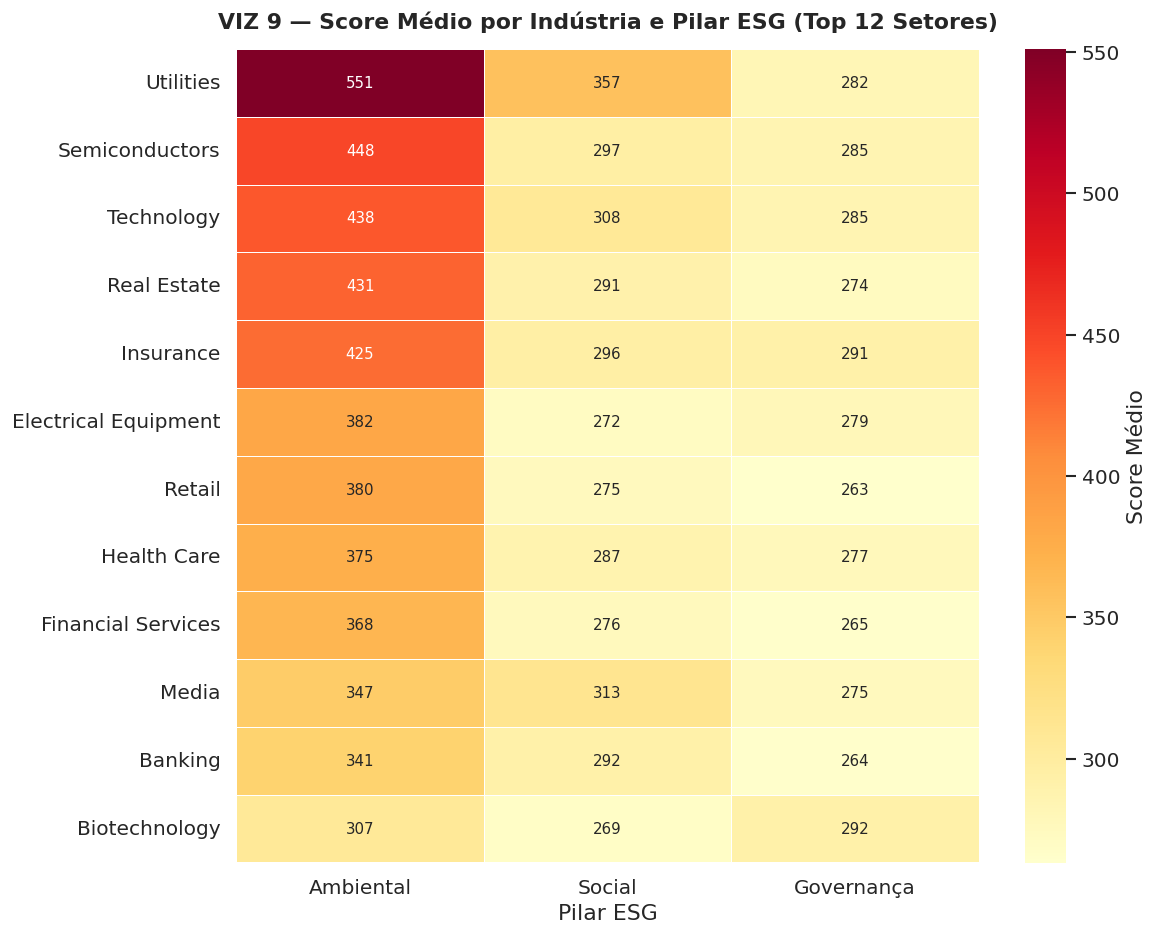

In [ ]:
top_industries = df.groupby('industry').size().nlargest(12).index
df_top = df[df['industry'].isin(top_industries)]
pivot = df_top.groupby('industry')[['environment_score', 'social_score', 'governance_score']].mean()
pivot.columns = ['Ambiental', 'Social', 'Governança']
pivot = pivot.sort_values('Ambiental', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Score Médio'}, annot_kws={'size': 9})
ax.set_title('VIZ 9 — Score Médio por Indústria e Pilar ESG (Top 12 Setores)',
             fontweight='bold', pad=12)
ax.set_xlabel('Pilar ESG')
ax.set_ylabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/viz9_heatmap_industria.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Identificar padrões setoriais nos pilares ESG e possíveis interações entre setor e desempenho.

INTERPRETAÇÃO:

O pilar Ambiental apresenta a maior variação entre setores, evidenciada pelo maior contraste no heatmap. Isso sugere que fatores ambientais dependem fortemente do tipo de indústria e do nível de regulação ao qual as empresas estão expostas.

Já o pilar Social apresenta comportamento mais uniforme, indicando que empresas de diferentes setores tendem a possuir práticas sociais relativamente semelhantes.

IMPACTO NA MODELAGEM:

A interação entre `Industry` e os pilares ESG pode gerar features de engenharia relevantes, ajudando o modelo a capturar padrões específicos de determinados setores.

### VIZ 10 — Violin Plot dos Sub-Scores por Classe

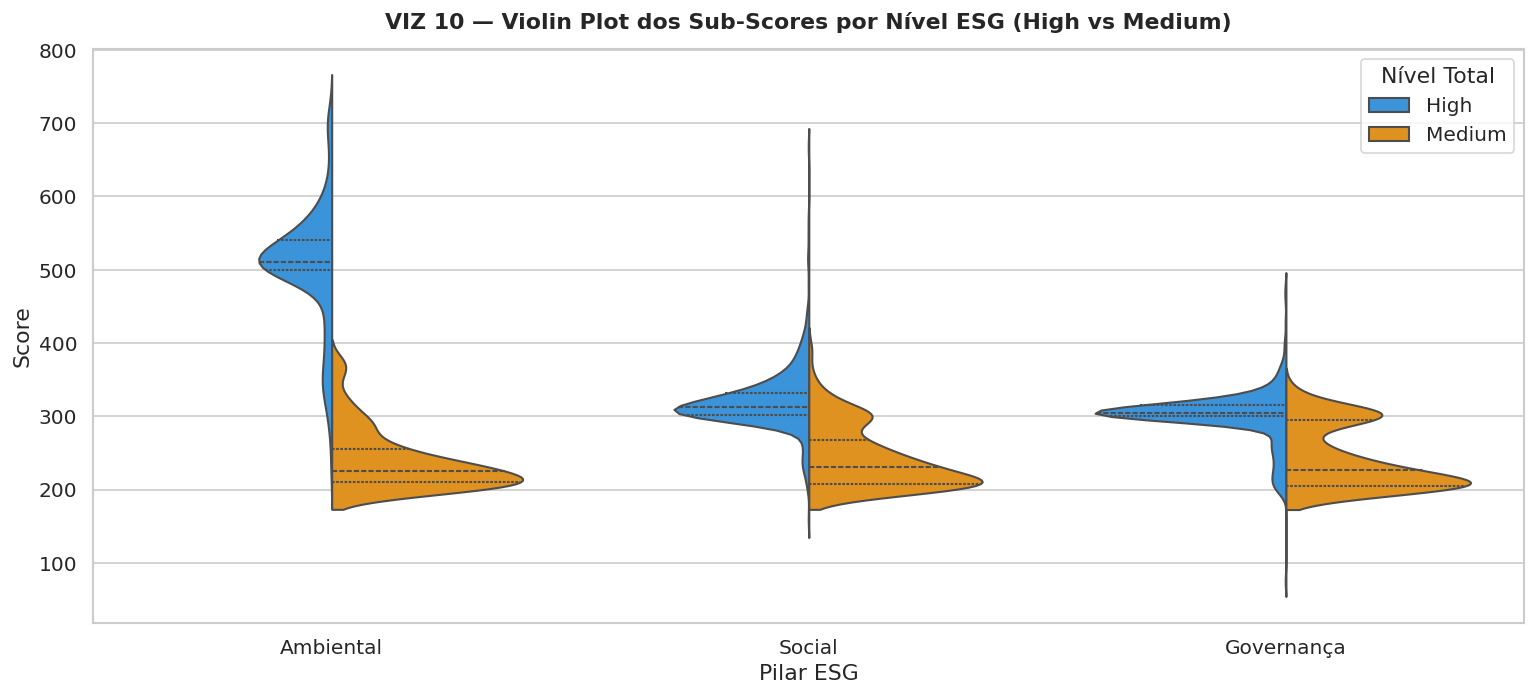

In [ ]:
df_melt = df[['environment_score', 'social_score',
               'governance_score', 'total_level']].melt(
    id_vars='total_level', var_name='Pilar', value_name='Score')
df_melt['Pilar'] = df_melt['Pilar'].map({
    'environment_score': 'Ambiental',
    'social_score': 'Social',
    'governance_score': 'Governança'
})

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=df_melt, x='Pilar', y='Score', hue='total_level',
               split=True, inner='quart',
               palette={'High': '#2196F3', 'Medium': '#FF9800'}, ax=ax)
ax.set_title('VIZ 10 — Violin Plot dos Sub-Scores por Nível ESG (High vs Medium)',
             fontweight='bold', pad=12)
ax.set_xlabel('Pilar ESG')
ax.set_ylabel('Score')
ax.legend(title='Nível Total')
plt.tight_layout()
plt.savefig('figures/viz10_violin.png', bbox_inches='tight', dpi=150)
plt.show()

OBJETIVO: Comparar formato, dispersão e separabilidade das distribuições ESG entre as classes.

INTERPRETAÇÃO:

O pilar Ambiental apresenta a separação mais clara entre empresas High e Medium, com menor sobreposição entre as distribuições. Isso indica alto poder discriminativo da variável `environment_score`.

Já os pilares Social e Governança apresentam sobreposição significativamente maior entre as classes, sugerindo menor capacidade de diferenciação quando analisados isoladamente.

Isso mostra que o desempenho ambiental é o principal fator associado à classificação ESG nesta base, enquanto os pilares Social e Governança atuam mais como variáveis complementares.

IMPACTO NA MODELAGEM:

O `environment_score` tende a possuir maior importância preditiva nos modelos, enquanto os pilares Social e Governança podem contribuir de forma complementar para melhorar a separação entre as classes.

---
## 6. Seleção de Features com Biblioteca (Scikit-learn)

### Metodologia

Utilizamos **três classificadores** para avaliar a importância das features, aplicados nos dois cenários (A e B):

**1. Decision Tree** (`sklearn.tree.DecisionTreeClassifier`)**:**  
Gera importância de features baseada na redução de impureza Gini em cada split. Simples, interpretável e não requer normalização dos dados. A importância indica o quanto cada feature contribui para as divisões da árvore.

**2. XGBoost** (`xgboost.XGBClassifier`)**:**  
Gradient Boosting otimizado que combina várias árvores de decisão fracas. A importância de features é calculada pelo ganho médio de cada feature nos splits de todas as árvores — captura relações não-lineares e interações complexas entre features.

**3. KNN** (`sklearn.neighbors.KNeighborsClassifier`)**:**  
O KNN não possui importância de features nativa (é um modelo baseado em distância). Por isso utilizamos **Permutation Importance** (`sklearn.inspection.permutation_importance`): embaralha cada feature aleatoriamente e mede o quanto o desempenho do modelo piora — quanto maior a queda, mais importante a feature.

**Por que esses três?**  
A combinação cobre abordagens distintas: Decision Tree e XGBoost são baseados em árvores (capturam não-linearidade), enquanto KNN com Permutation Importance avalia a feature pela sua contribuição real ao desempenho do modelo. Features importantes nos três métodos têm evidência robusta para entrar na modelagem.

In [ ]:
# KNN requer dados normalizados (sensível à escala)
scaler = MinMaxScaler()
X_A_scaled = scaler.fit_transform(X_A)
X_B_scaled = scaler.fit_transform(X_B)

print('Dados normalizados para KNN!')
print('X_A_scaled shape:', X_A_scaled.shape)
print('X_B_scaled shape:', X_B_scaled.shape)

Dados normalizados para KNN!
X_A_scaled shape: (722, 12)
X_B_scaled shape: (722, 6)


### 6.1 Seleção de features — Cenário A (COM sub-scores)

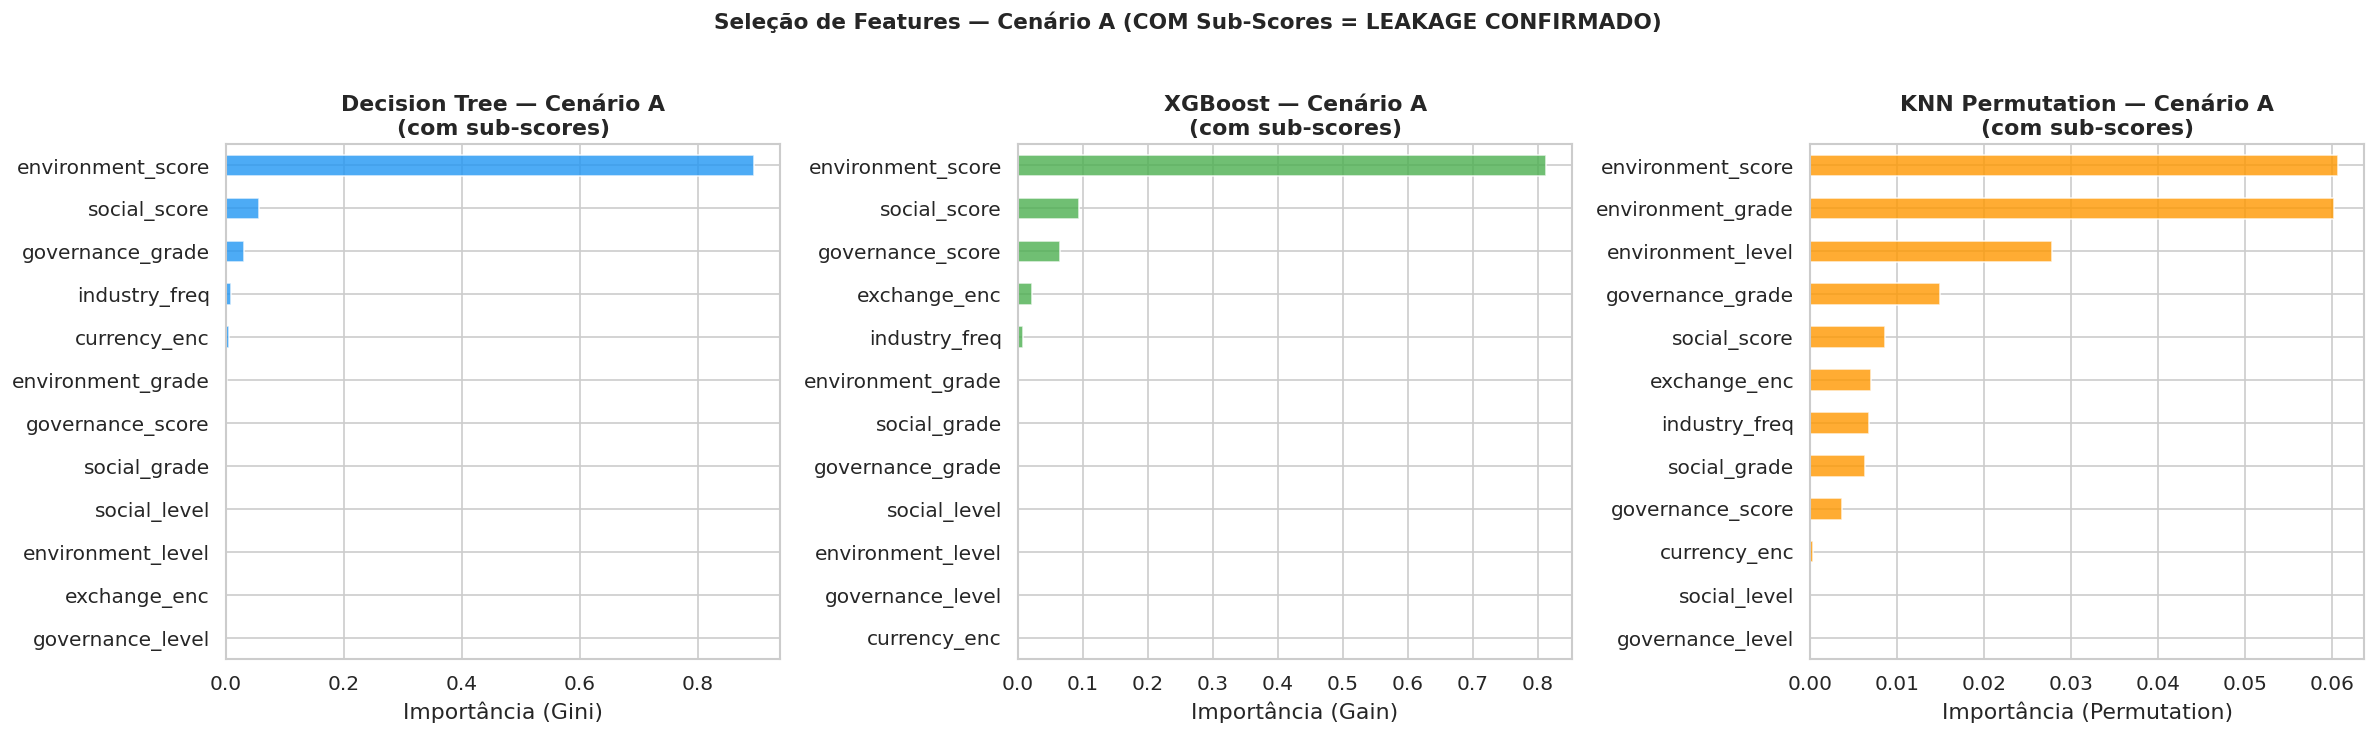

TOP FEATURES — CENÁRIO A:

Decision Tree:
environment_score    0.8954
social_score         0.0564
governance_grade     0.0304
industry_freq        0.0083
currency_enc         0.0061
environment_grade    0.0028
governance_score     0.0006
social_grade         0.0000
social_level         0.0000
environment_level    0.0000
exchange_enc         0.0000
governance_level     0.0000

XGBoost:
environment_score    0.8125
social_score         0.0936
governance_score     0.0647
exchange_enc         0.0211
industry_freq        0.0081
environment_grade    0.0000
social_grade         0.0000
governance_grade     0.0000
social_level         0.0000
environment_level    0.0000
governance_level     0.0000
currency_enc         0.0000

KNN (Permutation Importance):
environment_score    0.0607
environment_grade    0.0602
environment_level    0.0278
governance_grade     0.0150
social_score         0.0086
exchange_enc         0.0071
industry_freq        0.0068
social_grade         0.0064
governance_score     

In [ ]:
# --- Decision Tree ---
dt_A = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
dt_A.fit(X_A, y)
fi_dt_A = pd.Series(dt_A.feature_importances_, index=FEATURES_A).sort_values(ascending=False)

# --- XGBoost ---
xgb_A = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0,
                       scale_pos_weight=(y==0).sum()/(y==1).sum())
xgb_A.fit(X_A, y)
fi_xgb_A = pd.Series(xgb_A.feature_importances_, index=FEATURES_A).sort_values(ascending=False)

# --- KNN + Permutation Importance ---
knn_A = KNeighborsClassifier(n_neighbors=7)
knn_A.fit(X_A_scaled, y)
perm_A = permutation_importance(knn_A, X_A_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)
fi_knn_A = pd.Series(perm_A.importances_mean, index=FEATURES_A).sort_values(ascending=False)

# --- Visualização ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fi_dt_A.plot(kind='barh', ax=axes[0], color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].set_title('Decision Tree — Cenário A\n(com sub-scores)', fontweight='bold')
axes[0].set_xlabel('Importância (Gini)')
axes[0].invert_yaxis()

fi_xgb_A.plot(kind='barh', ax=axes[1], color='#4CAF50', alpha=0.8, edgecolor='white')
axes[1].set_title('XGBoost — Cenário A\n(com sub-scores)', fontweight='bold')
axes[1].set_xlabel('Importância (Gain)')
axes[1].invert_yaxis()

fi_knn_A.plot(kind='barh', ax=axes[2], color='#FF9800', alpha=0.8, edgecolor='white')
axes[2].set_title('KNN Permutation — Cenário A\n(com sub-scores)', fontweight='bold')
axes[2].set_xlabel('Importância (Permutation)')
axes[2].invert_yaxis()

plt.suptitle('Seleção de Features — Cenário A (COM Sub-Scores = LEAKAGE CONFIRMADO)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_selection_A.png', bbox_inches='tight', dpi=150)
plt.show()

print('TOP FEATURES — CENÁRIO A:')
print('\nDecision Tree:')
print(fi_dt_A.round(4).to_string())
print('\nXGBoost:')
print(fi_xgb_A.round(4).to_string())
print('\nKNN (Permutation Importance):')
print(fi_knn_A.round(4).to_string())

### 6.2 Seleção de features — Cenário B (SEM sub-scores)

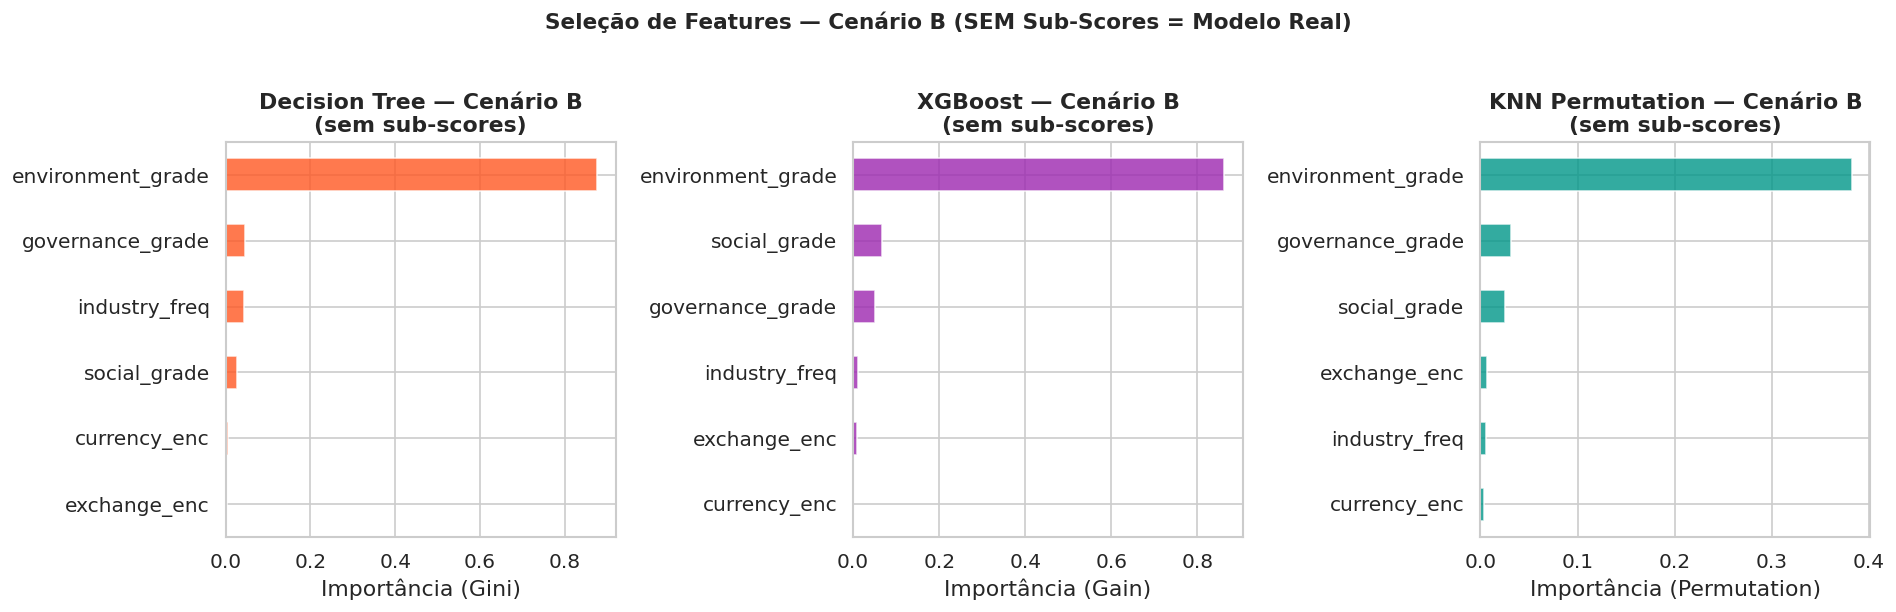

TOP FEATURES — CENÁRIO B:

Decision Tree:
environment_grade    0.8763
governance_grade     0.0456
industry_freq        0.0431
social_grade         0.0256
currency_enc         0.0064
exchange_enc         0.0030

XGBoost:
environment_grade    0.8627
social_grade         0.0664
governance_grade     0.0497
industry_freq        0.0112
exchange_enc         0.0099
currency_enc         0.0000

KNN (Permutation Importance):
environment_grade    0.3827
governance_grade     0.0313
social_grade         0.0248
exchange_enc         0.0066
industry_freq        0.0053
currency_enc         0.0032


In [ ]:
# --- Decision Tree ---
dt_B = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
dt_B.fit(X_B, y)
fi_dt_B = pd.Series(dt_B.feature_importances_, index=FEATURES_B).sort_values(ascending=False)

# --- XGBoost ---
xgb_B = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0,
                       scale_pos_weight=(y==0).sum()/(y==1).sum())
xgb_B.fit(X_B, y)
fi_xgb_B = pd.Series(xgb_B.feature_importances_, index=FEATURES_B).sort_values(ascending=False)

# --- KNN + Permutation Importance --
knn_B = KNeighborsClassifier(n_neighbors=7)
knn_B.fit(X_B_scaled, y)
perm_B = permutation_importance(knn_B, X_B_scaled, y, n_repeats=10, random_state=42, n_jobs=-1)
fi_knn_B = pd.Series(perm_B.importances_mean, index=FEATURES_B).sort_values(ascending=False)

# --- Visualização ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fi_dt_B.plot(kind='barh', ax=axes[0], color='#FF5722', alpha=0.8, edgecolor='white')
axes[0].set_title('Decision Tree — Cenário B\n(sem sub-scores)', fontweight='bold')
axes[0].set_xlabel('Importância (Gini)')
axes[0].invert_yaxis()

fi_xgb_B.plot(kind='barh', ax=axes[1], color='#9C27B0', alpha=0.8, edgecolor='white')
axes[1].set_title('XGBoost — Cenário B\n(sem sub-scores)', fontweight='bold')
axes[1].set_xlabel('Importância (Gain)')
axes[1].invert_yaxis()

fi_knn_B.plot(kind='barh', ax=axes[2], color='#009688', alpha=0.8, edgecolor='white')
axes[2].set_title('KNN Permutation — Cenário B\n(sem sub-scores)', fontweight='bold')
axes[2].set_xlabel('Importância (Permutation)')
axes[2].invert_yaxis()

plt.suptitle('Seleção de Features — Cenário B (SEM Sub-Scores = Modelo Real)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/feature_selection_B.png', bbox_inches='tight', dpi=150)
plt.show()

print('TOP FEATURES — CENÁRIO B:')
print('\nDecision Tree:')
print(fi_dt_B.round(4).to_string())
print('\nXGBoost:')
print(fi_xgb_B.round(4).to_string())
print('\nKNN (Permutation Importance):')
print(fi_knn_B.round(4).to_string())

### 6.3 Diagnóstico de leakage e features recomendadas

In [ ]:
print('=' * 65)
print('DIAGNÓSTICO DE DATA LEAKAGE')
print('=' * 65)
print()
print('CENÁRIO A (com sub-scores):')
print(f'  Top DT  : {fi_dt_A.index[0]} = {fi_dt_A.iloc[0]:.4f}')
print(f'  Top XGB : {fi_xgb_A.index[0]} = {fi_xgb_A.iloc[0]:.4f}')
print(f'  Top KNN : {fi_knn_A.index[0]} = {fi_knn_A.iloc[0]:.4f}')
print('   Sub-scores dominam os três métodos — LEAKAGE CONFIRMADO.')
print()
print('CENÁRIO B (sem sub-scores):')
print(f'  Top DT  : {fi_dt_B.index[0]} = {fi_dt_B.iloc[0]:.4f}')
print(f'  Top XGB : {fi_xgb_B.index[0]} = {fi_xgb_B.iloc[0]:.4f}')
print(f'  Top KNN : {fi_knn_B.index[0]} = {fi_knn_B.iloc[0]:.4f}')
print('   environment_grade lidera nos três métodos.')
print()
print('RANKING CONSOLIDADO — CENÁRIO B (média de posições):')
ranks = pd.DataFrame({
    'DT' : fi_dt_B.rank(ascending=False),
    'XGB': fi_xgb_B.rank(ascending=False),
    'KNN': fi_knn_B.rank(ascending=False)
})
ranks['rank_medio'] = ranks.mean(axis=1)
ranking_final = ranks.sort_values('rank_medio')

for i, (feat, row) in enumerate(ranking_final.iterrows(), 1):
    print(f'  {i}. {feat:25s} | DT={fi_dt_B.get(feat,0):.4f} | XGB={fi_xgb_B.get(feat,0):.4f} | KNN={fi_knn_B.get(feat,0):.4f}')

print()
print('JUSTIFICATIVA: Features rankeadas pelos três métodos simultaneamente.')
print('Evitar leakage garante desempenho realista em produção.')

DIAGNÓSTICO DE DATA LEAKAGE

CENÁRIO A (com sub-scores):
  Top DT  : environment_score = 0.8954
  Top XGB : environment_score = 0.8125
  Top KNN : environment_score = 0.0607
   Sub-scores dominam os três métodos — LEAKAGE CONFIRMADO.

CENÁRIO B (sem sub-scores):
  Top DT  : environment_grade = 0.8763
  Top XGB : environment_grade = 0.8627
  Top KNN : environment_grade = 0.3830
   environment_grade lidera nos três métodos.

RANKING CONSOLIDADO — CENÁRIO B (média de posições):
  1. environment_grade         | DT=0.8763 | XGB=0.8627 | KNN=0.3830
  2. governance_grade          | DT=0.0456 | XGB=0.0497 | KNN=0.0320
  3. social_grade              | DT=0.0256 | XGB=0.0664 | KNN=0.0252
  4. industry_freq             | DT=0.0431 | XGB=0.0112 | KNN=0.0055
  5. exchange_enc              | DT=0.0030 | XGB=0.0099 | KNN=0.0066
  6. currency_enc              | DT=0.0064 | XGB=0.0000 | KNN=0.0032

JUSTIFICATIVA: Features rankeadas pelos três métodos simultaneamente.
Evitar leakage garante desempenho r

---
## 7. Conclusões da EDA

### Principais Achados

1. **Desbalanceamento moderado de classes**: 62.5% High vs 37.5% Medium. Por não possuir outras classes como Low ou Excellent para o modelo aprender, acaba se tornando um problema crítico. Como só temos duas classes recomenda-se `class_weight='balanced'` e monitorar F1-macro na avaliação.

2. **Data leakage confirmado nos sub-scores**: Os sub-scores numéricos são componentes diretos de `total_score`, que determina o target `total_level`. O Cenário A serve apenas como benchmark para quantificar o efeito do leakage.

3. **Pilar ambiental como preditor dominante**: `environment_grade` lidera nos três métodos (Decision Tree, XGBoost e KNN com Permutation Importance) no Cenário B — é o feature mais informativo sem leakage.

4. **Pilares social e governança com baixa variação**: Grades concentradas em BB/B para quase todas as empresas limitam o poder discriminativo individual desses pilares.

5. **Indústria relevante mas de alta cardinalidade**: 48 categorias exigem Target Encoding com validação cruzada na modelagem para evitar novo leakage.

6. **Exchange com impacto marginal**: NYSE tem scores ligeiramente superiores; diferença pequena, mas útil como feature de contexto.

7. **Dataset de alta qualidade**: Sem duplicatas, apenas 13 nulos em `industry` (1.8%), tratados com preenchimento por 'Unknown'.

---

## 8. Próximos Passos

Para a próxima entrega, o planejamento envolve as seguintes etapas de modelagem e validação:

- **Modelagem principal (Cenário B)**: treinar e comparar KNN, Decision Tree e XGBoost com as features selecionadas pelo ranking consolidado. Esses mesmos algoritmos já utilizados na seleção de features serão agora ajustados e avaliados como modelos finais.

- **Validação cruzada**: utilizar StratifiedKFold com k=5 para preservar a proporção das classes em cada fold e garantir uma estimativa confiável do desempenho real dos modelos.

- **Métricas de avaliação**: Accuracy como métrica principal, complementada por ROC-AUC, Precision, Recall e Confusion Matrix para análise detalhada por classe.

- **Otimização de hiperparâmetros**: aplicar GridSearchCV para ajustar os parâmetros de cada modelo (ex: profundidade da árvore, número de vizinhos no KNN, taxa de aprendizado do XGBoost).

- **Rastreamento de experimentos**: registrar todos os experimentos no MLflow, incluindo hiperparâmetros, métricas e artefatos, garantindo reprodutibilidade e facilidade de comparação entre modelos.